## Plot the E1's

In [78]:
# Load the files back as the same dict to be able to start from here next time

import pandas as pd
import numpy as np

eig_dict = {}
resolutions = [10_000, 50_000, 100_000]

for resolution in resolutions:
    eig_dict[resolution] = {}
    eig_dict[resolution]['X'] = pd.read_csv(
        f"../data/eigs/sperm_X.chr8.eigs.{resolution}.arms.cis.vecs.tsv",
        sep="\t"
    )
    eig_dict[resolution]['Y'] = pd.read_csv(
        f"../data/eigs/sperm_Y.chr8.eigs.{resolution}.arms.cis.vecs.tsv",
        sep="\t"
    )



In [79]:
import matplotlib.pyplot as plt
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

plt.style.use('smaller.mplstyle')

import numpy as np


from scipy.stats import norm

def plot_e1_distribution(df, e1_column='E1', start_column='start', bins=51, title=None):
    """
    Plots the histogram and normal distributions of E1 values for A and B compartments.

    Parameters:
        df (pd.DataFrame): DataFrame containing the data.
        e1_column (str): Column name for E1 values.
        start_column (str): Column name for start positions (optional, not used in the plot).
        bins (int): Number of bins for the histogram.
    """
    x = df[start_column].values
    y = df[e1_column].values

    f, ax = plt.subplots()
    xmin, xmax = ax.set_xlim(-2,2)
    bins = np.linspace(xmin, xmax, bins)

    # A compartments
    ax.hist(y[y > 0], bins=bins, color="tab:red", alpha=0.5, label="A", )
    # B compartments
    ax.hist(y[y < 0], bins=bins, color="tab:blue", alpha=0.5, label="B",)
    # Mean values (vline)
    ax.axvline(y[y > 0].mean(), color="tab:red", linestyle="--", label="Mean A")
    ax.axvline(y[y < 0].mean(), color="tab:blue", linestyle="--", label="Mean B")

    # # Plot the normal distributions
    # x_values = np.linspace(y.min(), y.max(), 1000)
    # mean_a = np.median(y[y > 0])
    # mean_b = np.median(y[y < 0])
    # std_a = y[y > 0].std()
    # std_b = y[y < 0].std()

    # ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
    # ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
    # stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
    # ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

    # Final touches
    plt.xlabel("E1")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


# Plot the E1 tracks saved in a dict

def plot_eigenvectors(df, title=None, scatter=True, scatter_alpha=0.5):
    fig, ax = plt.subplots(figsize=(6, 1))

    x = df['start']
    y = df['E1']

    # # Make stairs
    # x_stairs = np.zeros(2* len(x))
    # x_stairs[::2] = x
    # x_stairs[1::2] = x + resolution
    # y_stairs = np.zeros(2* len(y))
    # y_stairs[::2] = y
    # y_stairs[1::2] = y


    if scatter:
        ax.scatter(x, y, s=0.4, color='k', alpha=scatter_alpha, ec='None')
    ax.fill_between(x, y, where = y<0, color='tab:blue', lw=1, ec='None', step='post', interpolate=True)
    ax.fill_between(x, y, where = y>0, color='tab:red', lw=1, ec='None', step='post', interpolate=True) 
    ax.set_title(title)
    ax.set_ylabel('E1')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(-1,1)
    ax.set_xlabel('Genomic Position (Mbp)')
    ticks = np.arange(0, x.max(), step=100*resolution)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{int(t/1e6)}' for t in ticks])
    ax.spines[:].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    plt.tight_layout()
    plt.show()




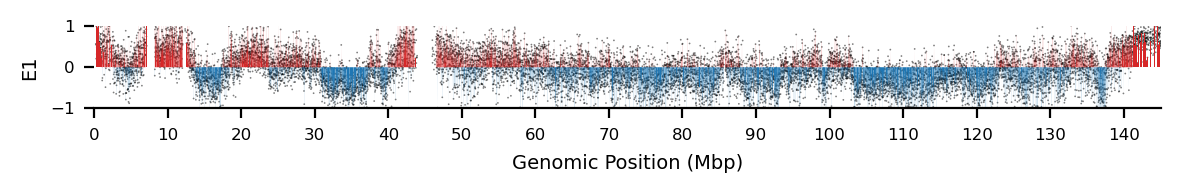

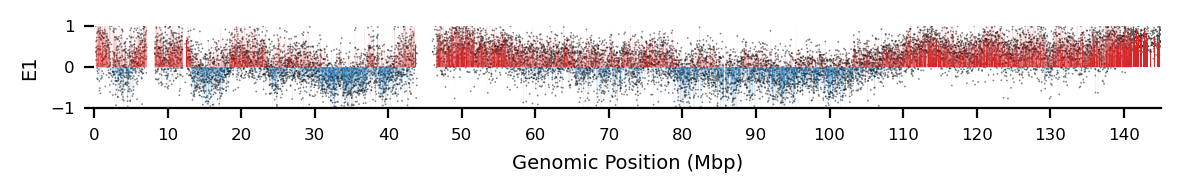

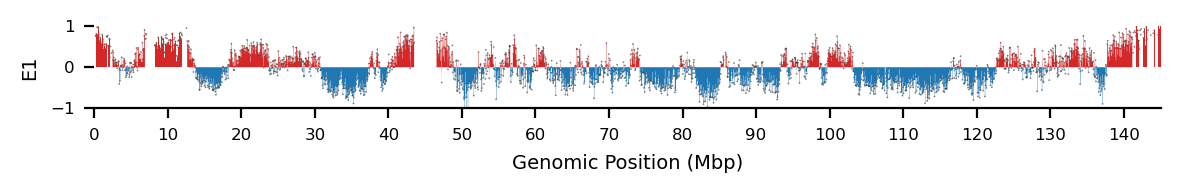

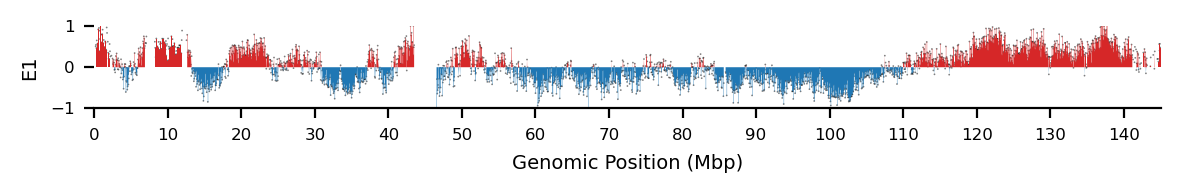

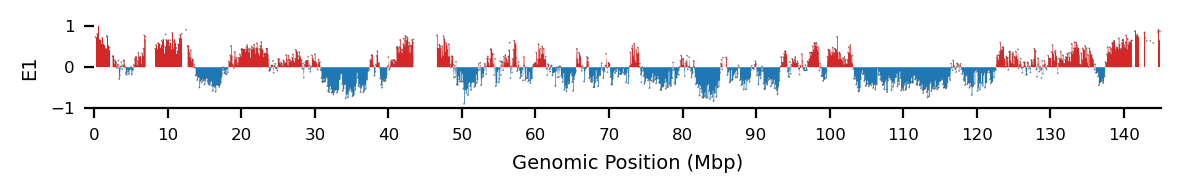

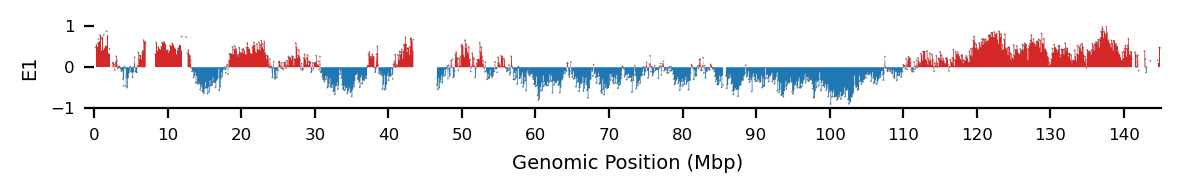

In [80]:
#| echo: false
#| label: fig-chr8-eigs
#| fig-cap: "Comparing the eigenvector E1 for chr8 in X- and Y-bearing sperm at different resolutions. Here, the eigenvectors are re-sorted by their Spearman correlation with the GC content."
#| fig-scap: "Compare chr8 E1 for X/Y-bearing sperm"
#| fig-subcap:
#|  - "E1 for X-bearing sperm (10kb)"
#|  - "E1 for Y-bearing sperm (10kb)"
#|  - "E1 for X-bearing sperm (50kb)"
#|  - "E1 for Y-bearing sperm (50kb)"
#|  - "E1 for X-bearing sperm (100kb)"
#|  - "E1 for Y-bearing sperm (100kb)"
#| layout-ncol: 1


for res, dict in eig_dict.items():
    df_e1_x = dict['X']
    df_e1_y = dict['Y']
    
    plot_eigenvectors(df_e1_x, title=None)

    
    plot_eigenvectors(df_e1_y, title=None)


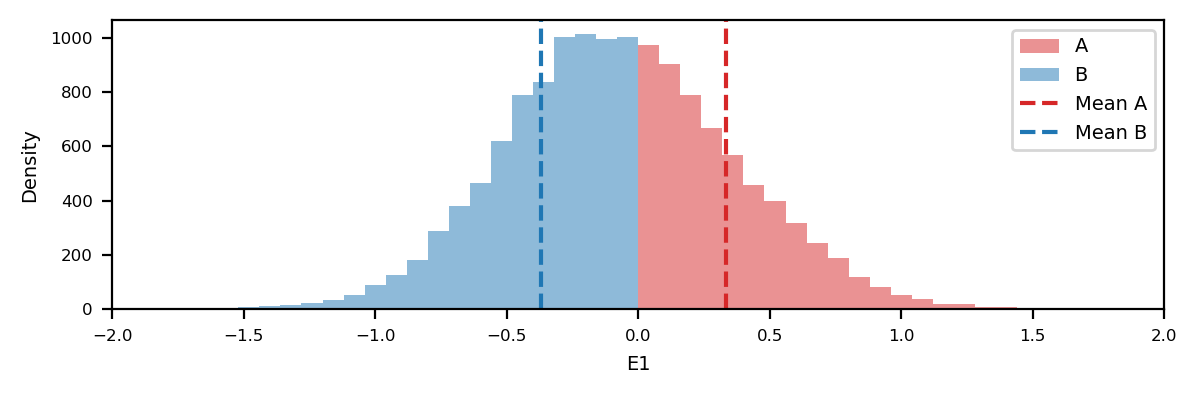

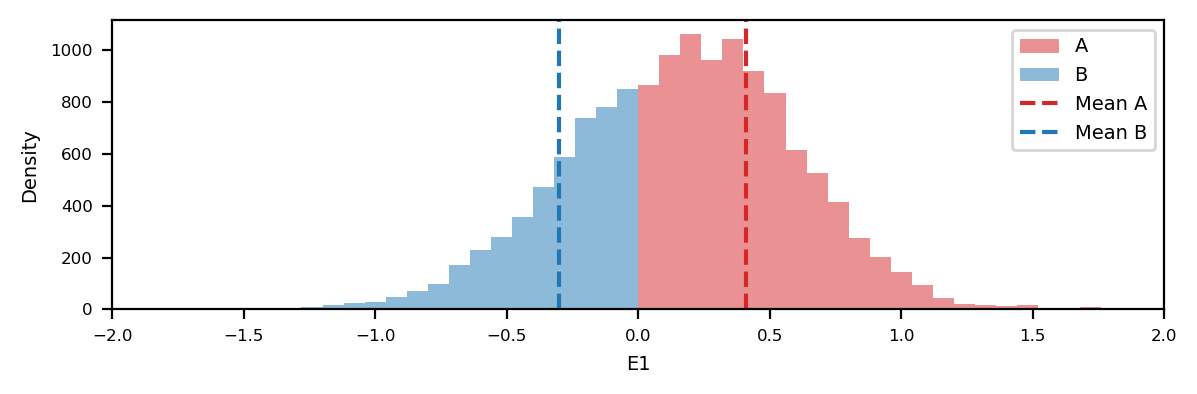

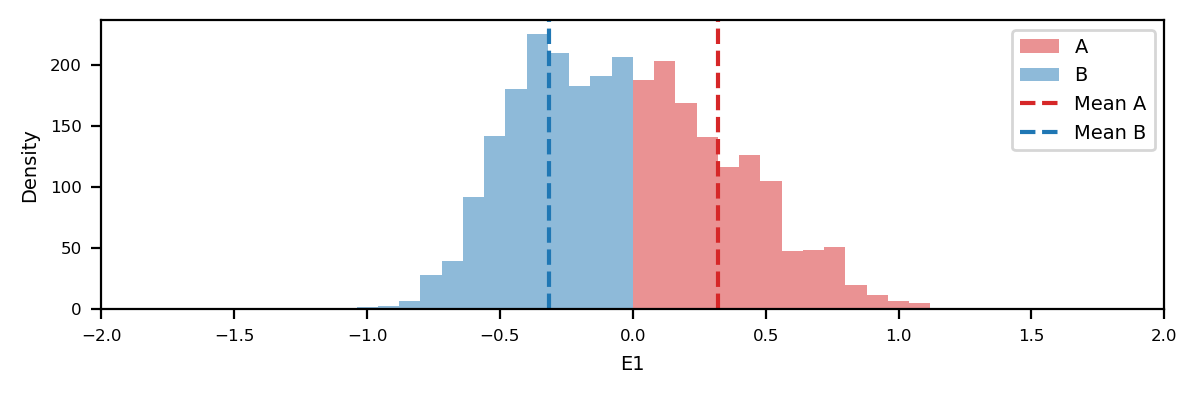

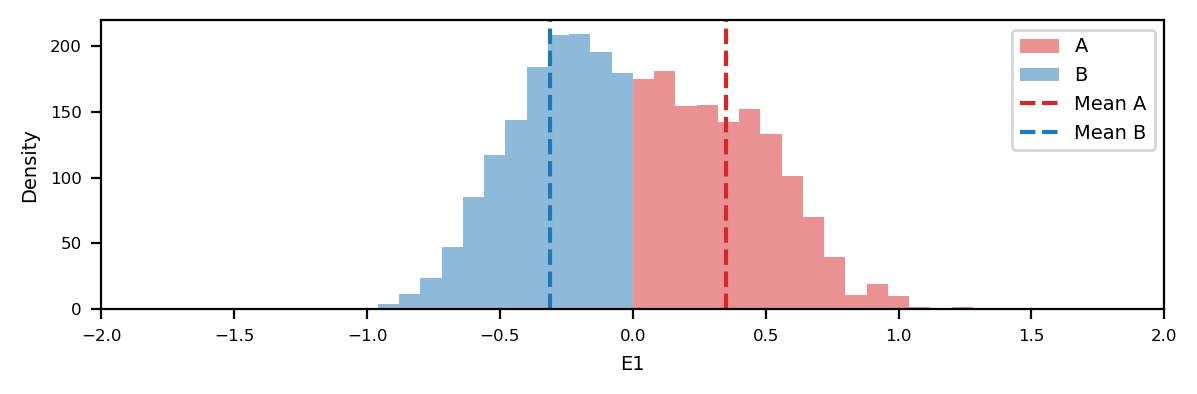

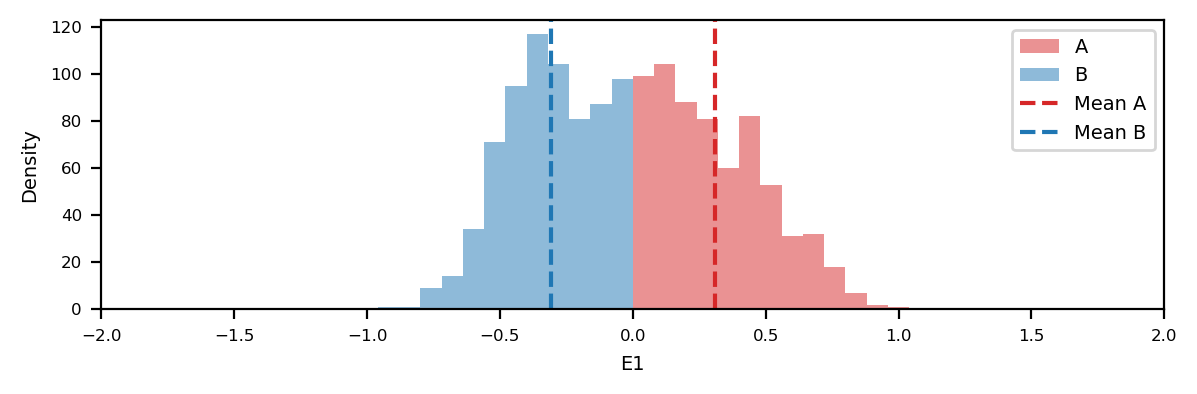

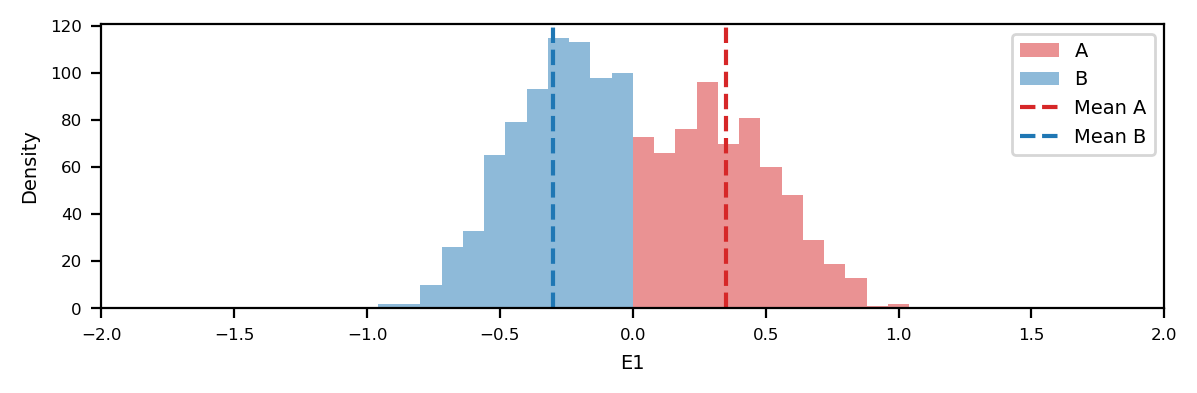

In [81]:

for res, dict in eig_dict.items():
    df_e1_x = dict['X']
    df_e1_y = dict['Y']
    
    plot_e1_distribution(df_e1_x, title=None)
    plot_e1_distribution(df_e1_y, title=None)

## Load back the traces

To be able to start from here

In [40]:
import arviz as az
import numpy as np

In [55]:
# Decide resolution to load 
resolution = 50_000  
resname = f"{resolution//1000}kb"

trace_dir = "../results/traces/"
chr8_x_NNHN_path = f"{trace_dir}/12.chr8.{resname}.X.mix.arms.trace.nc"
chr8_y_NNHN_path = f"{trace_dir}/12.chr8.{resname}.Y.mix.arms.trace.nc"
chr8_x_NTHN_path = f"{trace_dir}/12.chr8.{resname}.X.NTHN.mix.arms.trace.nc"
chr8_y_NTHN_path = f"{trace_dir}/12.chr8.{resname}.Y.NTHN.mix.arms.trace.nc"



traces = {f'{resname}.X.NNHN': az.from_netcdf(chr8_x_NNHN_path),
          f'{resname}.Y.NNHN': az.from_netcdf(chr8_y_NNHN_path),
          f'{resname}.X.NTHN': az.from_netcdf(chr8_x_NTHN_path),
          f'{resname}.Y.NTHN': az.from_netcdf(chr8_y_NTHN_path)}

traces[f'{resname}.X.NNHN']

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [56]:
display(
    az.summary(traces[f'{resname}.X.NNHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.Y.NNHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.X.NTHN'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces[f'{resname}.Y.NTHN'], var_names=["mu", "sigma", "grw_sigma"]),
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.308,0.009,-0.325,-0.291,0.0,0.0,11739.0,6430.0,1.0
mu[A],0.283,0.011,0.262,0.304,0.0,0.0,11064.0,5915.0,1.0
sigma[B],0.217,0.006,0.206,0.227,0.0,0.0,11200.0,6418.0,1.0
sigma[A],0.266,0.006,0.254,0.278,0.0,0.0,13982.0,5411.0,1.0
grw_sigma,0.079,0.003,0.073,0.086,0.0,0.0,11785.0,5813.0,1.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.267,0.007,-0.280,-0.254,0.0,0.0,13970.0,5439.0,1.0
mu[A],0.371,0.009,0.356,0.387,0.0,0.0,9717.0,5706.0,1.0
sigma[B],0.230,0.005,0.222,0.239,0.0,0.0,15087.0,5406.0,1.0
sigma[A],0.236,0.006,0.226,0.247,0.0,0.0,16271.0,4621.0,1.0
grw_sigma,0.067,0.003,0.061,0.073,0.0,0.0,16385.0,4981.0,1.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.228,0.124,-0.348,-0.073,0.046,0.007,11.0,134.0,1.68
mu[A],0.115,0.172,-0.097,0.281,0.065,0.009,11.0,172.0,1.68
sigma[B],0.366,0.193,0.190,0.613,0.072,0.011,11.0,142.0,1.68
sigma[A],0.273,0.010,0.257,0.292,0.003,0.000,12.0,161.0,1.60
grw_sigma,0.601,0.090,0.443,0.735,0.030,0.004,11.0,146.0,1.66


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.241,0.073,-0.288,-0.059,0.027,0.028,17.0,25.0,1.33
mu[A],0.309,0.152,-0.069,0.389,0.057,0.058,17.0,24.0,1.33
sigma[B],0.270,0.106,0.216,0.533,0.040,0.040,17.0,24.0,1.34
sigma[A],0.236,0.007,0.224,0.250,0.002,0.001,28.0,26.0,1.17
grw_sigma,0.526,0.041,0.447,0.599,0.001,0.001,1803.0,3496.0,1.01


In [57]:
# get the w variable and stack for each model

w_vars = {name: trace.posterior.w.stack(sample=('chain', 'draw')) for name, trace in traces.items()}

for key,w in w_vars.items():
    print(f"Model: {key}")
    display(w)

Model: 50kb.X.NNHN


<xarray.DataArray 'w' (pos: 2756, sample: 7000)> Size: 154MB
array([[0.51226774, 0.55249781, 0.49440935, ..., 0.53288832, 0.50339592,
        0.51184087],
       [0.5531108 , 0.56779149, 0.5164516 , ..., 0.54653697, 0.51845554,
        0.52562093],
       [0.56299517, 0.58717682, 0.52753153, ..., 0.53286682, 0.50831667,
        0.55144109],
       ...,
       [0.93987793, 0.98137978, 0.93409951, ..., 0.9883227 , 0.98353203,
        0.91456499],
       [0.94444558, 0.97966102, 0.93853664, ..., 0.99015179, 0.98425247,
        0.91501085],
       [0.93658765, 0.98083618, 0.9365489 , ..., 0.98977649, 0.98452572,
        0.9179868 ]], shape=(2756, 7000))
Coordinates:
  * pos      (pos) int64 22kB 200000 250000 300000 ... 144950000 145000000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 50kb.Y.NNHN


<xarray.DataArray 'w' (pos: 2757, sample: 7000)> Size: 154MB
array([[0.49480325, 0.5043139 , 0.49391771, ..., 0.50564863, 0.50005208,
        0.5274194 ],
       [0.49077217, 0.50778494, 0.49746131, ..., 0.54772844, 0.48984508,
        0.56217537],
       [0.5000332 , 0.53226965, 0.48707453, ..., 0.53898343, 0.53019414,
        0.54112574],
       ...,
       [0.99907171, 0.99788248, 0.99890093, ..., 0.99670484, 0.99846062,
        0.99517233],
       [0.99910056, 0.99776893, 0.99879799, ..., 0.99614849, 0.99860573,
        0.99469411],
       [0.99912661, 0.99785791, 0.99889884, ..., 0.99585689, 0.99877839,
        0.99382829]], shape=(2757, 7000))
Coordinates:
  * pos      (pos) int64 22kB 200000 250000 300000 ... 144950000 145000000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 50kb.X.NTHN


<xarray.DataArray 'w' (pos: 2756, sample: 7000)> Size: 154MB
array([[0.45000781, 0.91934404, 0.29058764, ..., 0.77867842, 0.5934942 ,
        0.62265334],
       [0.73767227, 0.91103621, 0.53452989, ..., 0.75330968, 0.88972594,
        0.9438828 ],
       [0.9264861 , 0.912212  , 0.83395125, ..., 0.88425531, 0.86792887,
        0.96238658],
       ...,
       [0.99999868, 0.99999953, 0.99998393, ..., 0.99999988, 0.9422029 ,
        0.9999965 ],
       [0.99999895, 0.9999995 , 0.99998305, ..., 0.99999995, 0.85914256,
        0.99999505],
       [0.99999946, 0.99999891, 0.99999298, ..., 0.99999998, 0.49505399,
        0.99998876]], shape=(2756, 7000))
Coordinates:
  * pos      (pos) int64 22kB 200000 250000 300000 ... 144950000 145000000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 50kb.Y.NTHN


<xarray.DataArray 'w' (pos: 2757, sample: 7000)> Size: 154MB
array([[2.73192039e-01, 9.31434841e-01, 9.09809171e-01, ...,
        3.88324881e-01, 3.61888628e-01, 4.31143525e-01],
       [5.10295071e-01, 9.54029681e-01, 9.63338112e-01, ...,
        3.27008771e-01, 2.64497146e-01, 2.80984833e-01],
       [4.76222896e-01, 9.60339882e-01, 9.48001296e-01, ...,
        2.68036157e-01, 1.09955476e-01, 2.05433087e-01],
       ...,
       [1.00000000e+00, 9.99998251e-01, 9.99999872e-01, ...,
        4.12236888e-01, 1.30217454e-01, 3.22307910e-09],
       [1.00000000e+00, 9.99998181e-01, 9.99999861e-01, ...,
        3.64069990e-01, 1.39185741e-01, 1.99421868e-09],
       [1.00000000e+00, 9.99999219e-01, 9.99999957e-01, ...,
        2.40508819e-01, 4.03210368e-01, 5.84237295e-09]],
      shape=(2757, 7000))
Coordinates:
  * pos      (pos) int64 22kB 200000 250000 300000 ... 144950000 145000000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

In [58]:
import matplotlib.pyplot as plt
import arviz as az
plt.style.use('smaller.mplstyle')

def plot_traces_and_energy(traces, trace_keys=None, var_names=['mu', 'sigma', 'grw_sigma'], figsize=(6, 4), layout='tight'):
    """
    Plot traces and energy plots for specified keys in the traces dictionary.

    Parameters:
        traces (dict): Dictionary containing ArviZ trace objects.
        trace_keys (list): List of keys in the traces dictionary to plot.
        var_names (list): List of variable names to include in the trace plots.
        figsize (tuple): Figure size for the subplots.
        layout (str): Layout option for the plots (e.g., 'tight').
    """
    if trace_keys is None:
        trace_keys = list(traces.keys())

    for key in trace_keys:
        # Plot trace
        f, axs = plt.subplots(3, 2, figsize=figsize, layout=layout)
        az.plot_trace(
            traces[key],
            var_names=var_names,
            compact=True,
            axes=axs,
            trace_kwargs={'linewidth': 0.3, 'alpha': 0.5},
            plot_kwargs={'alpha': 0.5, 'linewidth': 0.5}
        )
        for ax in axs.ravel():
            ax.title.set_fontsize(8)
            ax.xaxis.label.set_size(7)
            ax.yaxis.label.set_size(7)
            ax.tick_params(labelsize=6)

        plt.suptitle(f'Trace plots for {key}', fontsize=10)

    # Make a grid of energy plots
    ncols = 2
    nrows = int(np.ceil(len(trace_keys) / ncols))
    f, axs = plt.subplots(ncols, nrows, figsize=(6, 2*nrows), layout=layout)
    axs = axs.ravel()
    for i,key in enumerate(trace_keys):
        ax = axs[i]
        ax.set_title(f'Energy plot for {key}')
        az.plot_energy(traces[key], backend_kwargs={'layout': layout}, ax=ax)

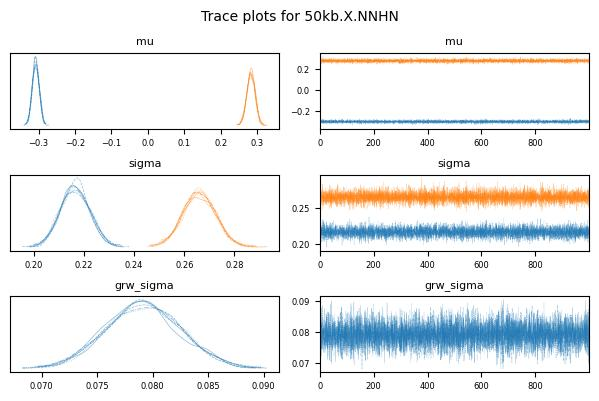

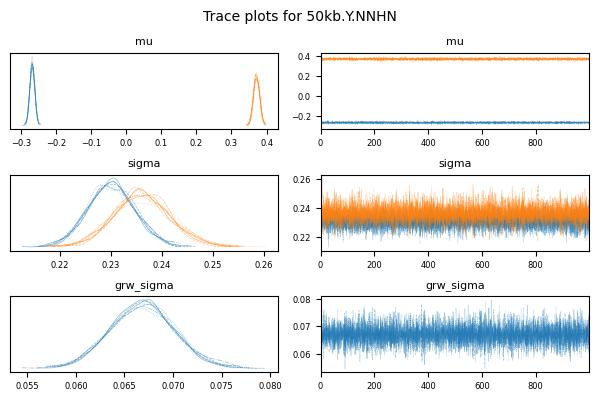

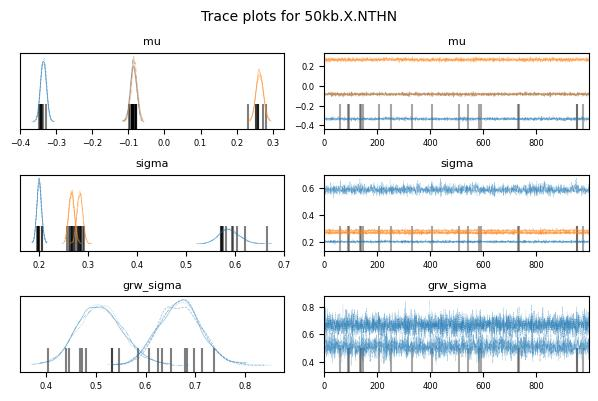

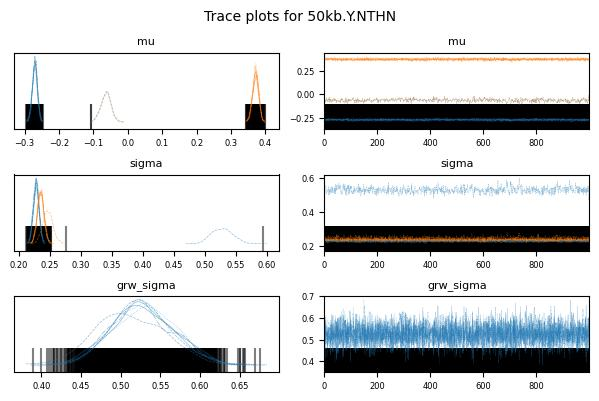

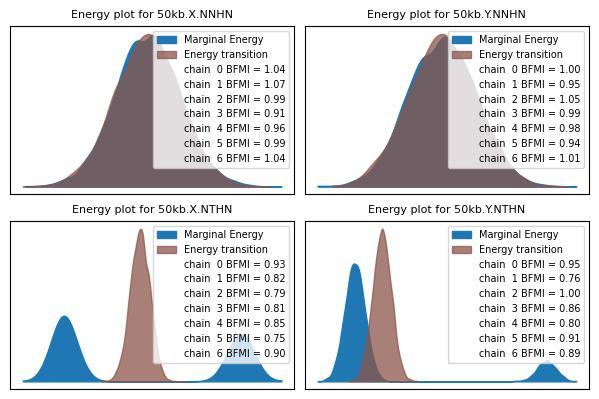

In [59]:
plot_traces_and_energy(traces)

array([[<Axes: title={'center': 'mu\nB'}>,
        <Axes: title={'center': 'mu\nB'}>],
       [<Axes: title={'center': 'mu\nA'}>,
        <Axes: title={'center': 'mu\nA'}>]], dtype=object)

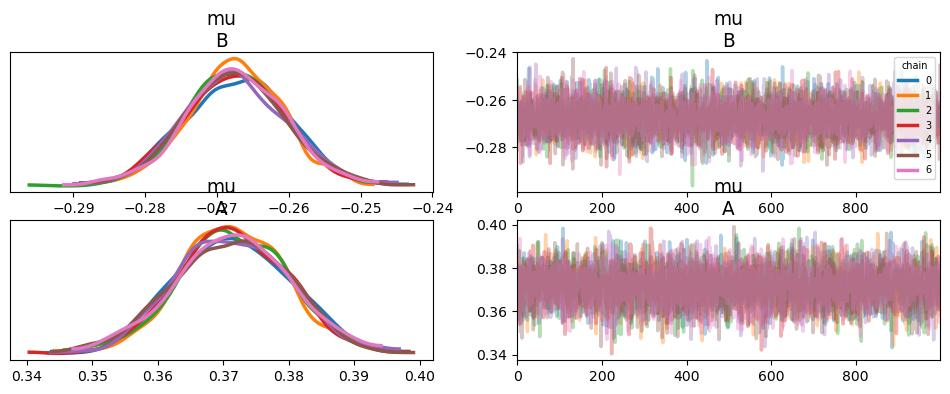

In [60]:
import matplotlib.pyplot as plt
tmp_trace = traces[f'{resname}.Y.NNHN']
az.plot_trace(tmp_trace, var_names=["mu"], compact=False, legend=True)

Model: 50kb.X.NNHN, non-empty bins: 2756


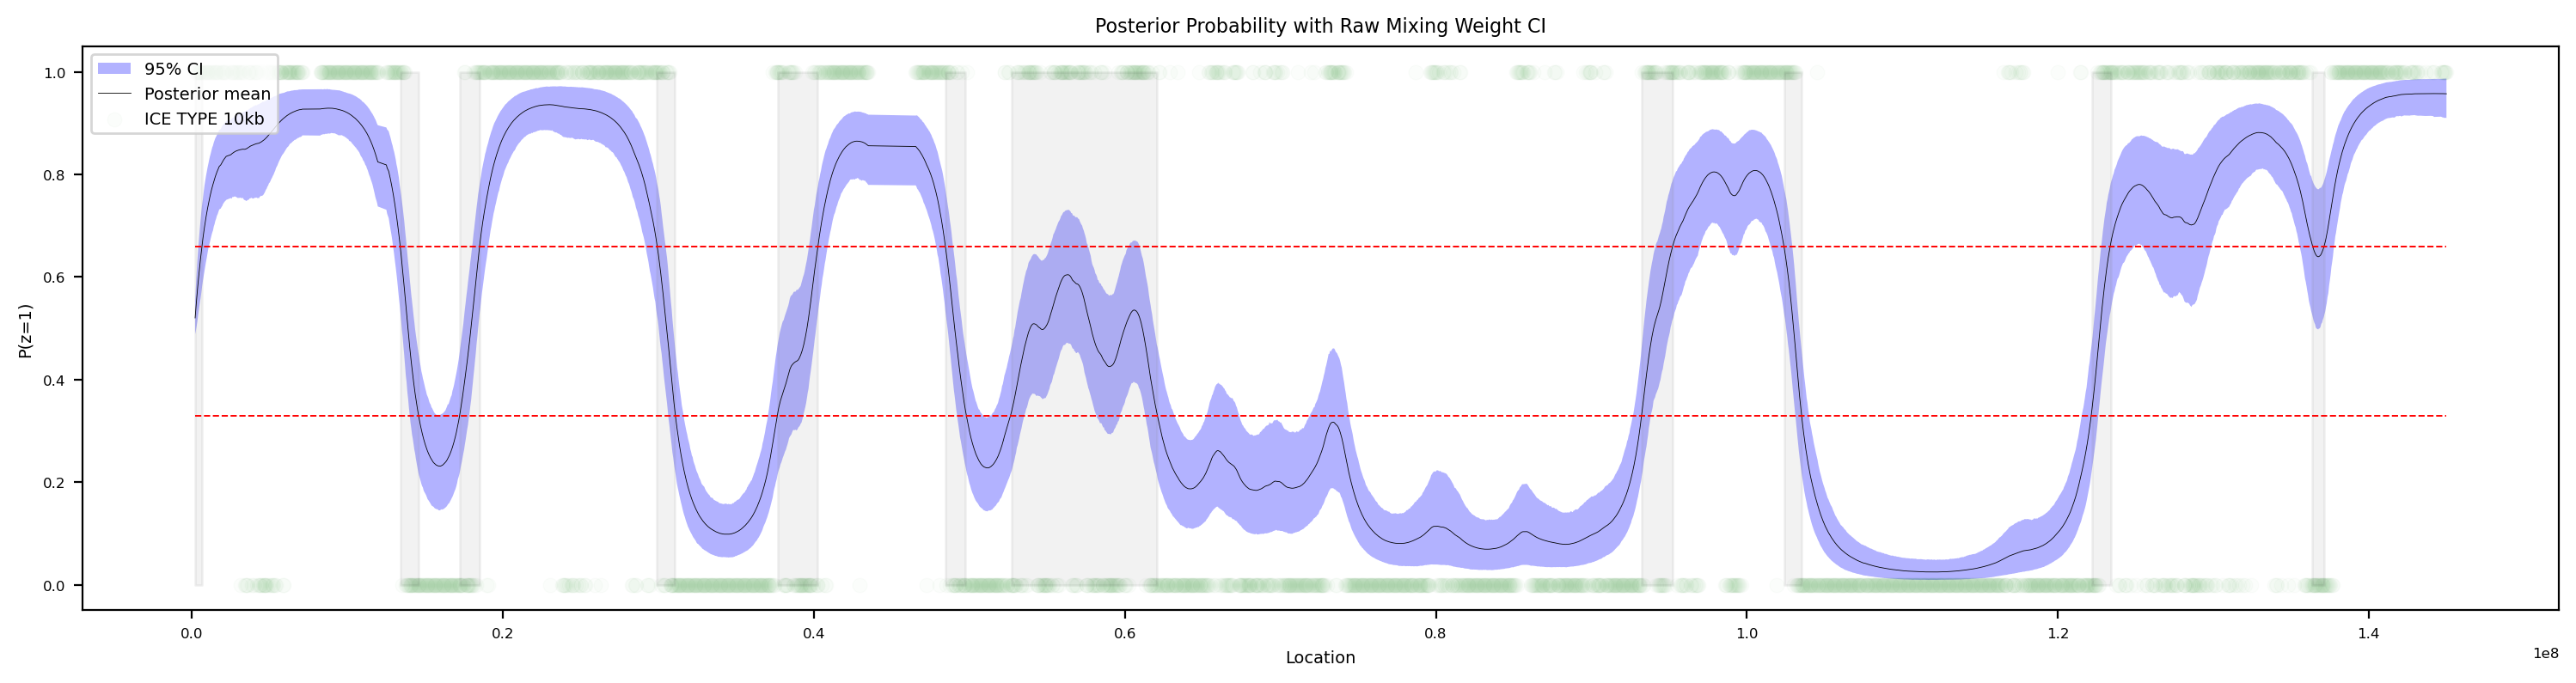

Model: 50kb.Y.NNHN, non-empty bins: 2757


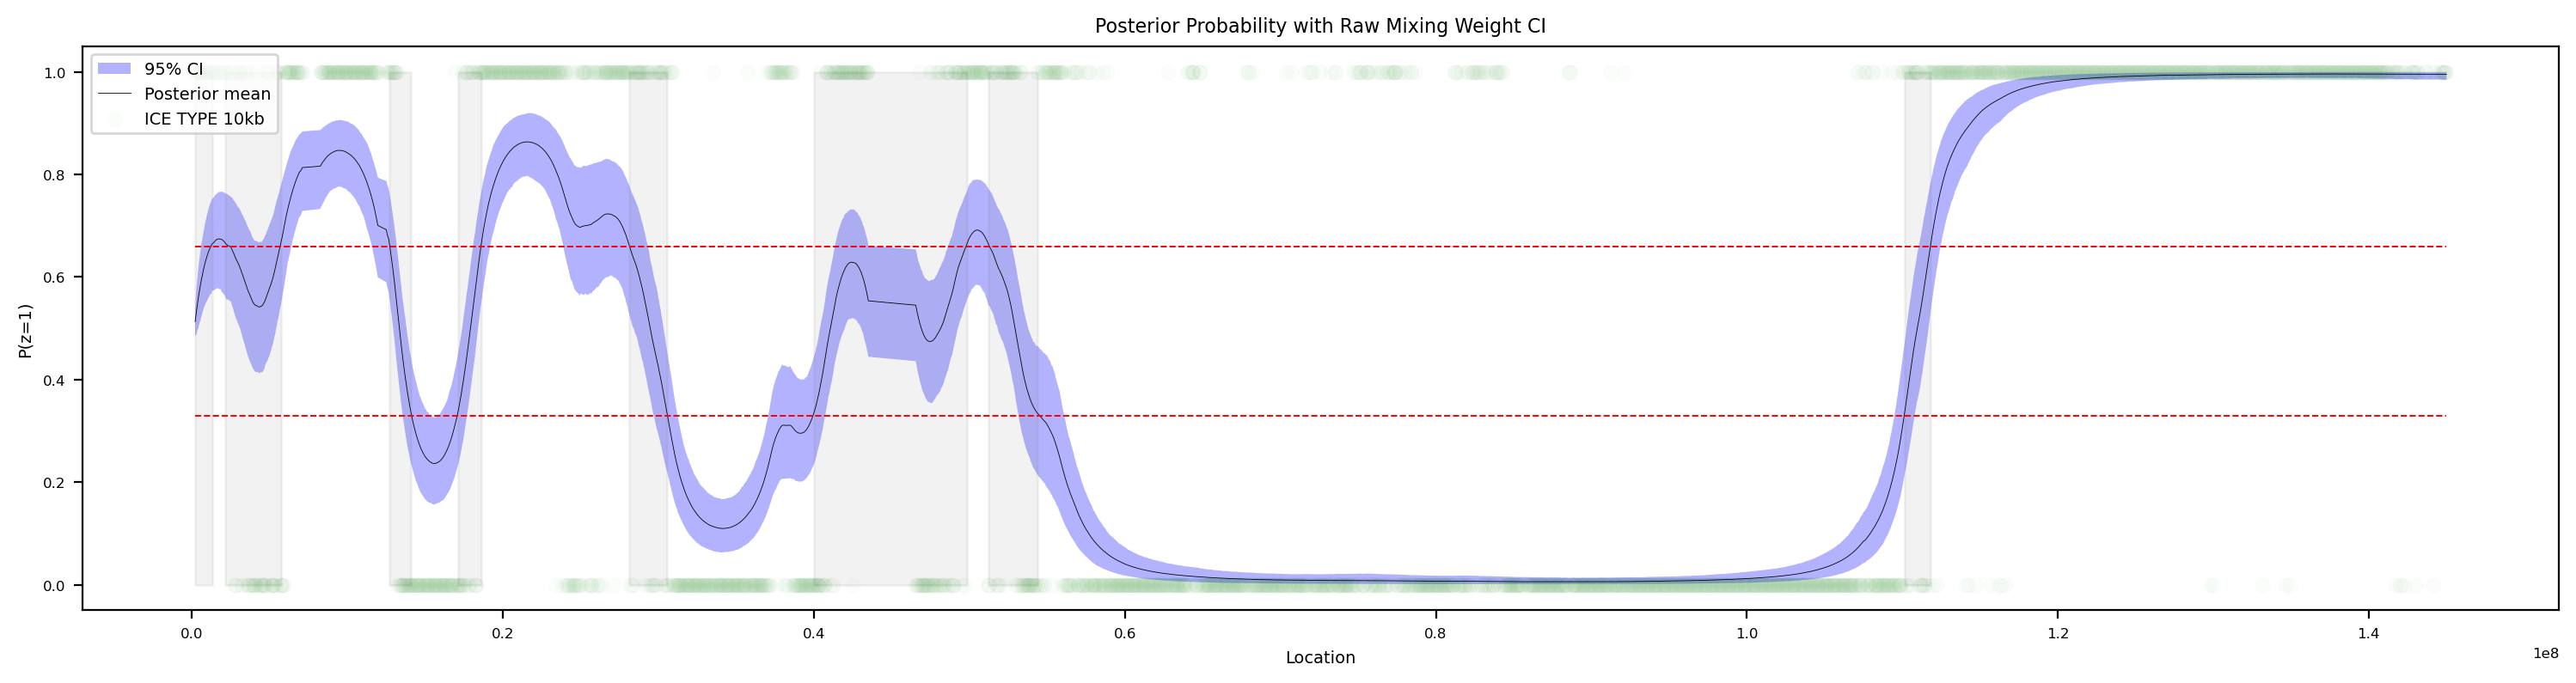

Model: 50kb.X.NTHN, non-empty bins: 2756


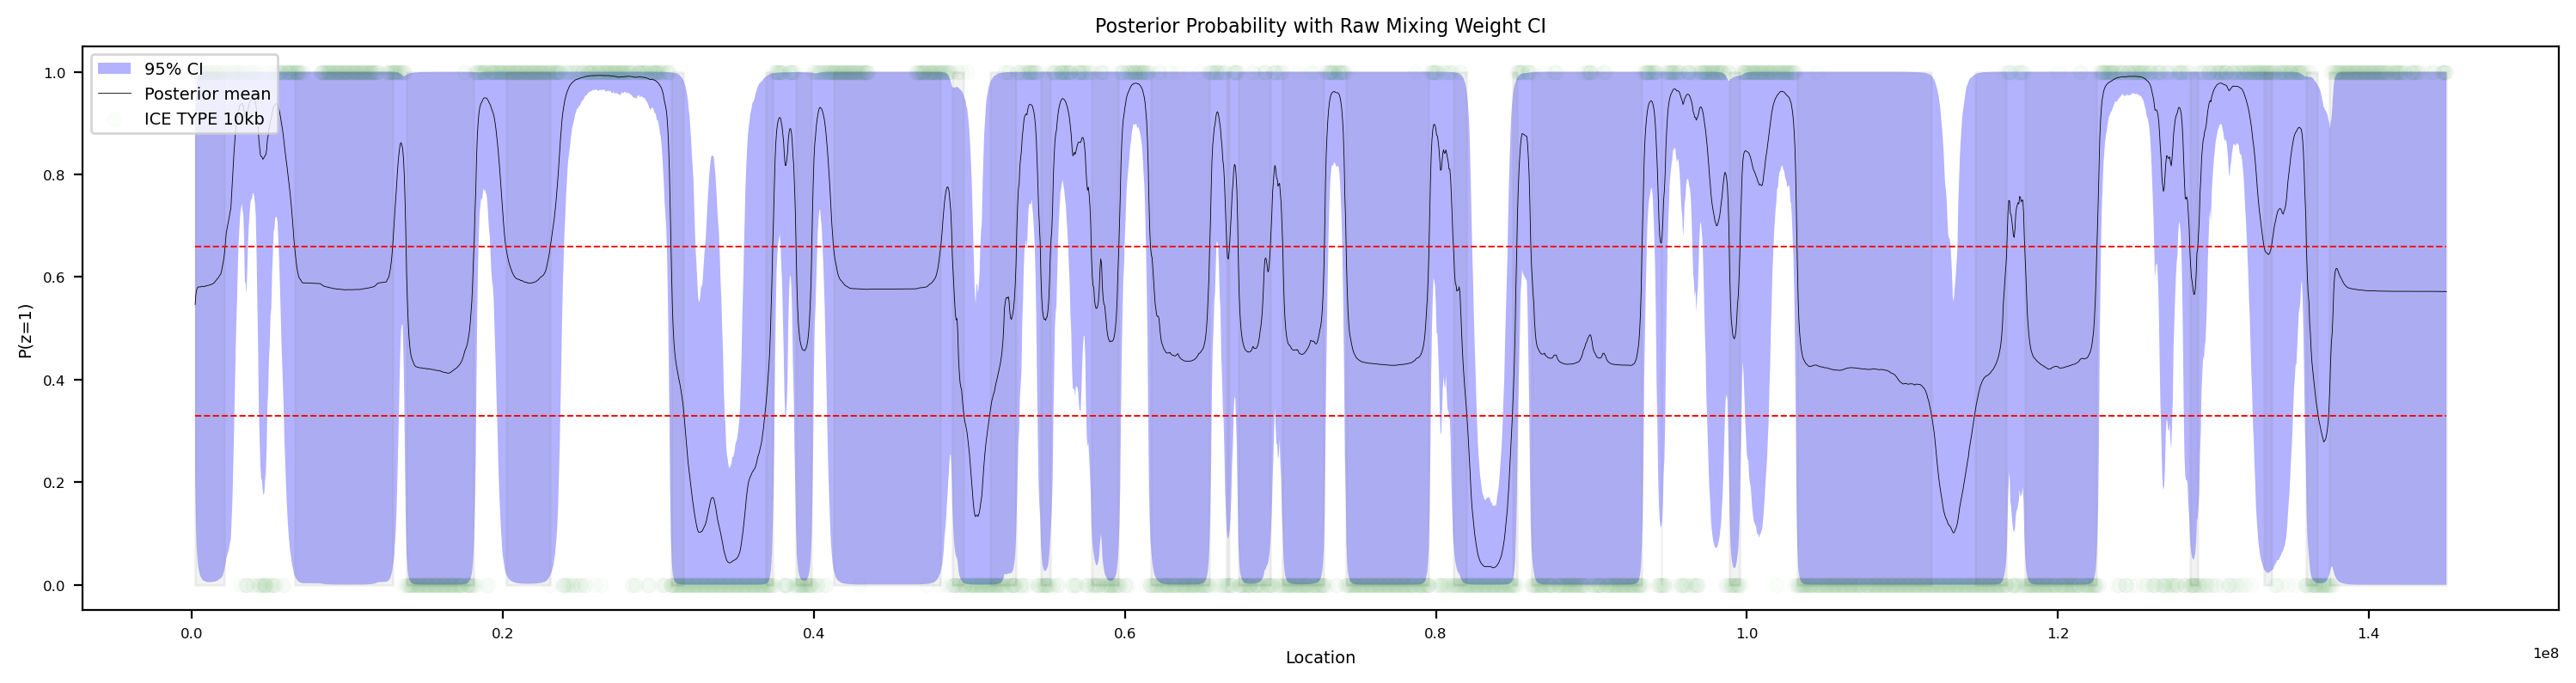

Model: 50kb.Y.NTHN, non-empty bins: 2757


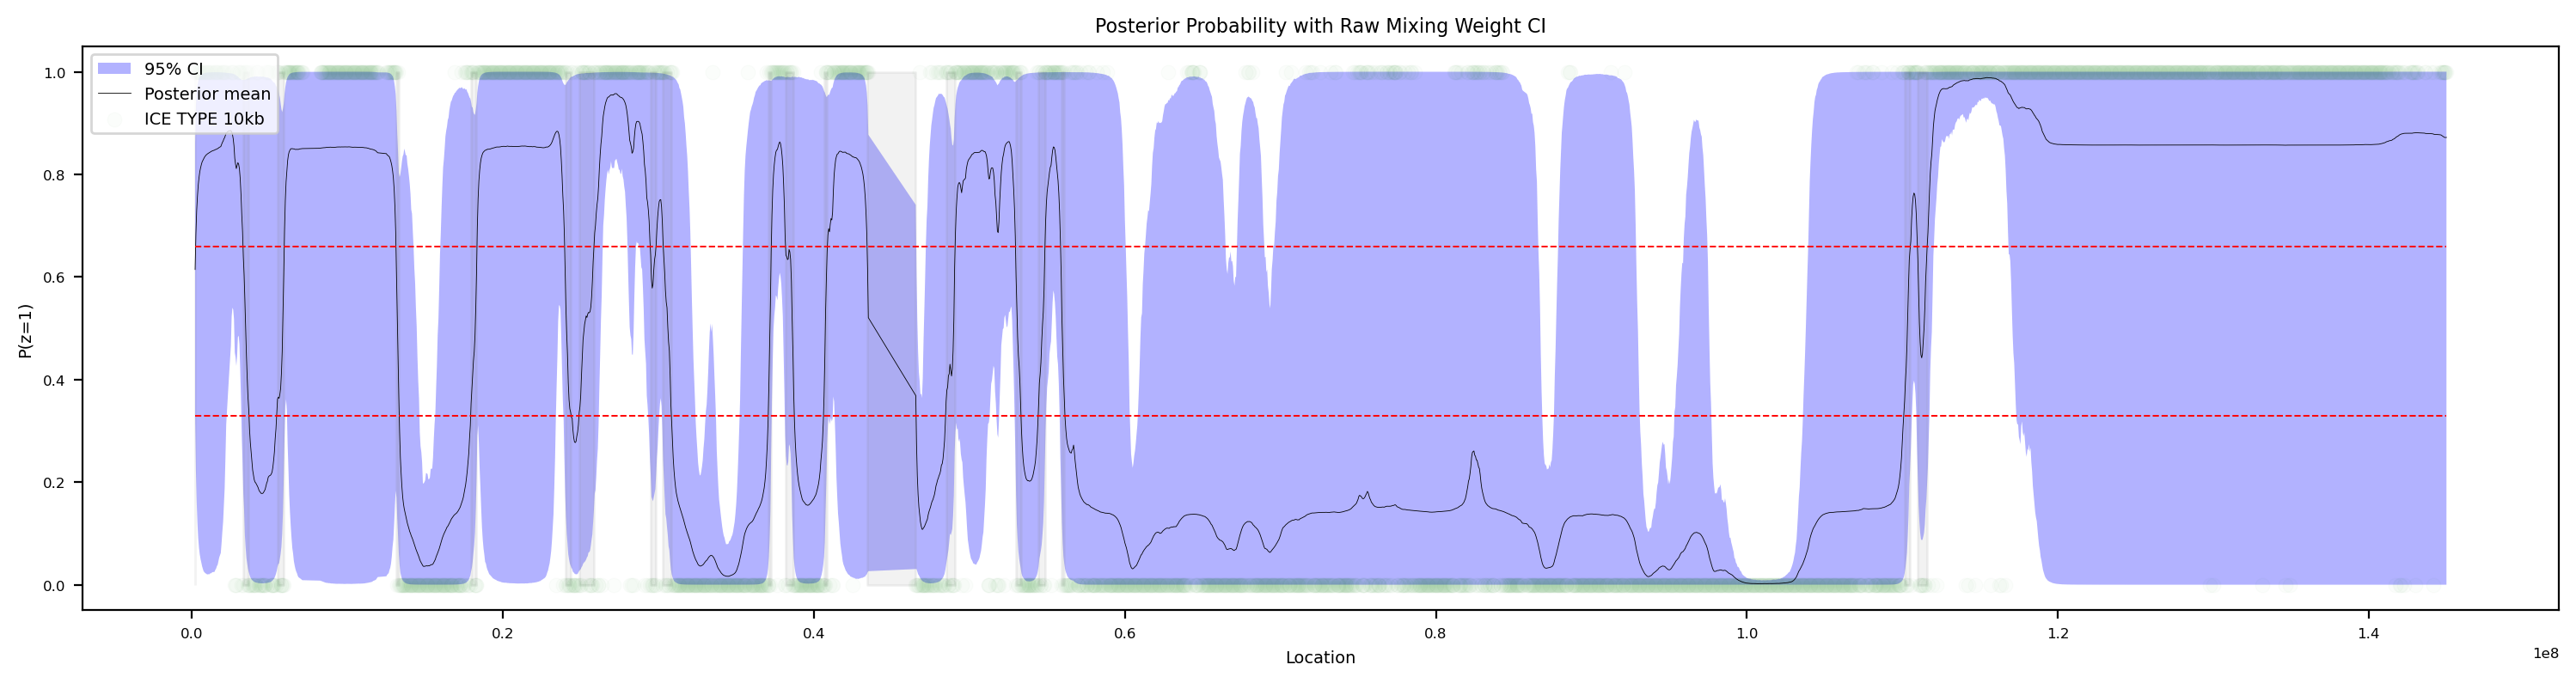

In [61]:
import matplotlib.pyplot as plt

# Set matplotlib to display retina format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

for name, w_stack in w_vars.items():
    print(f"Model: {name}, non-empty bins: {w_stack.pos.size}")   
    w_mean = w_stack.mean(dim=('sample'))
    w_ci_direct = w_stack.quantile([0.05, 0.95], dim=("sample"))
    w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)
    w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)

    x = w_stack["pos"]

    f, ax = plt.subplots(figsize=(15, 4))

    ax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )

    x_grey = x.copy()
    x_grey = x_grey.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    # Grey band
    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    # # Compare e1 predictions
    e1 = traces[name].observed_data.y_hat.values
    hard_assign =  e1 > 0

    ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

    ax.scatter(x, hard_assign, label="ICE TYPE 10kb", color="green", linewidth=0.5, alpha=0.015)

    # Plot the 0.5 line
    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.7)

    plt.ylabel("P(z=1)")
    plt.xlabel("Location")
    plt.legend(loc='upper left')
    plt.title("Posterior Probability with Raw Mixing Weight CI")
    plt.tight_layout()
    plt.show()




In [62]:
# Subset 200 draws from each chain of w_stack

w_subset = w_stack.sel(draw=slice(0,149))
n_chains = np.unique(w_stack.chain)



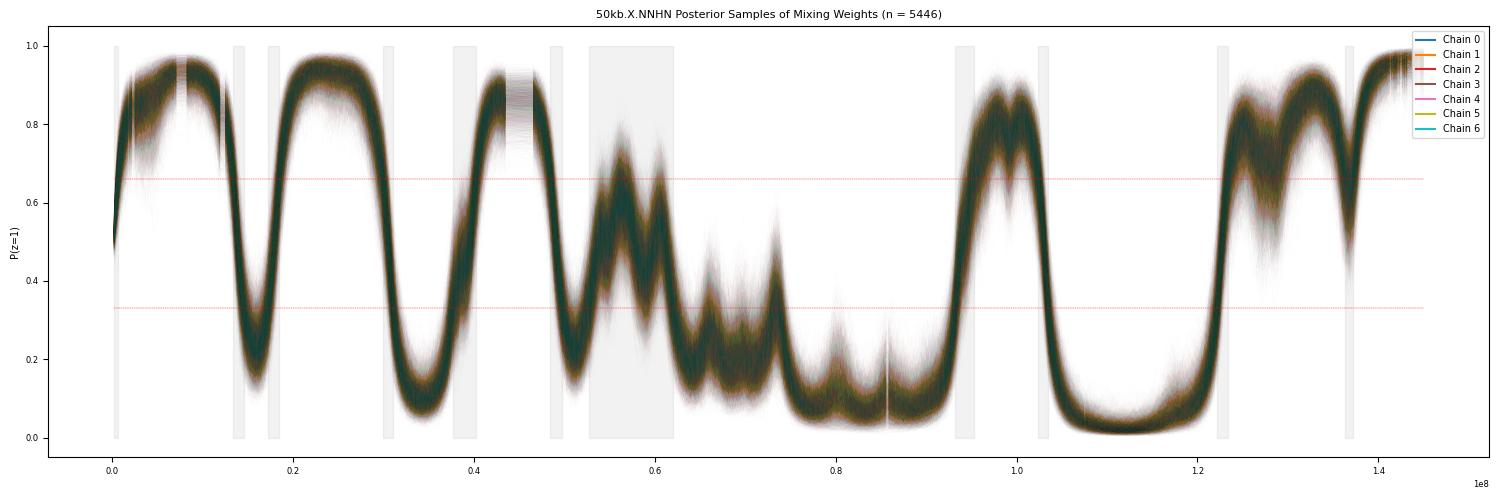

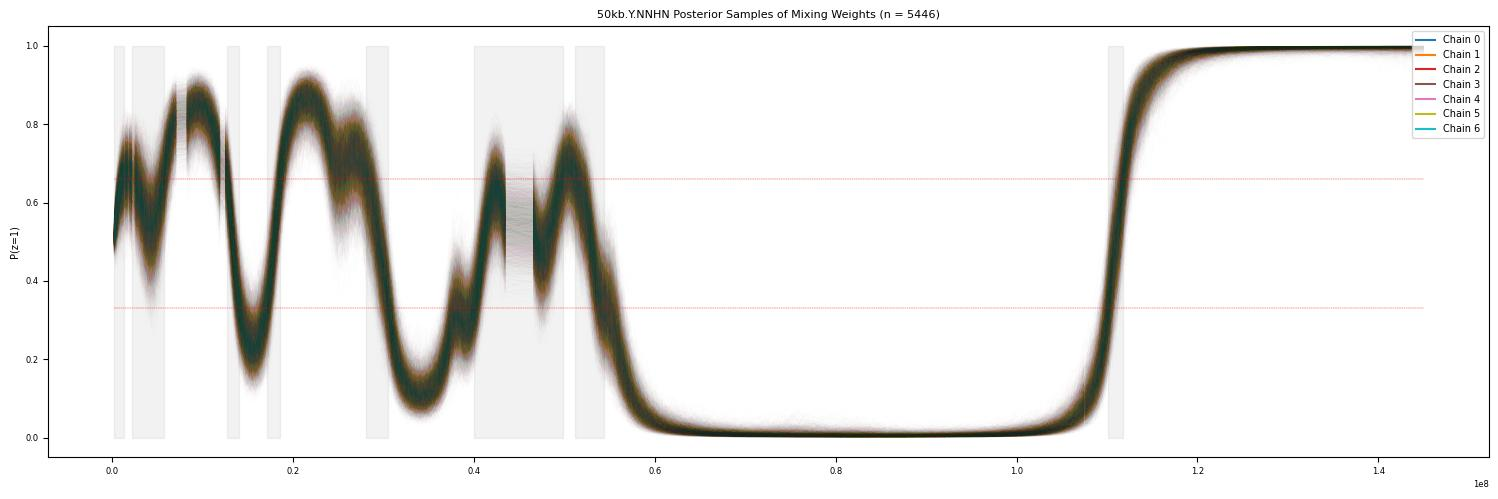

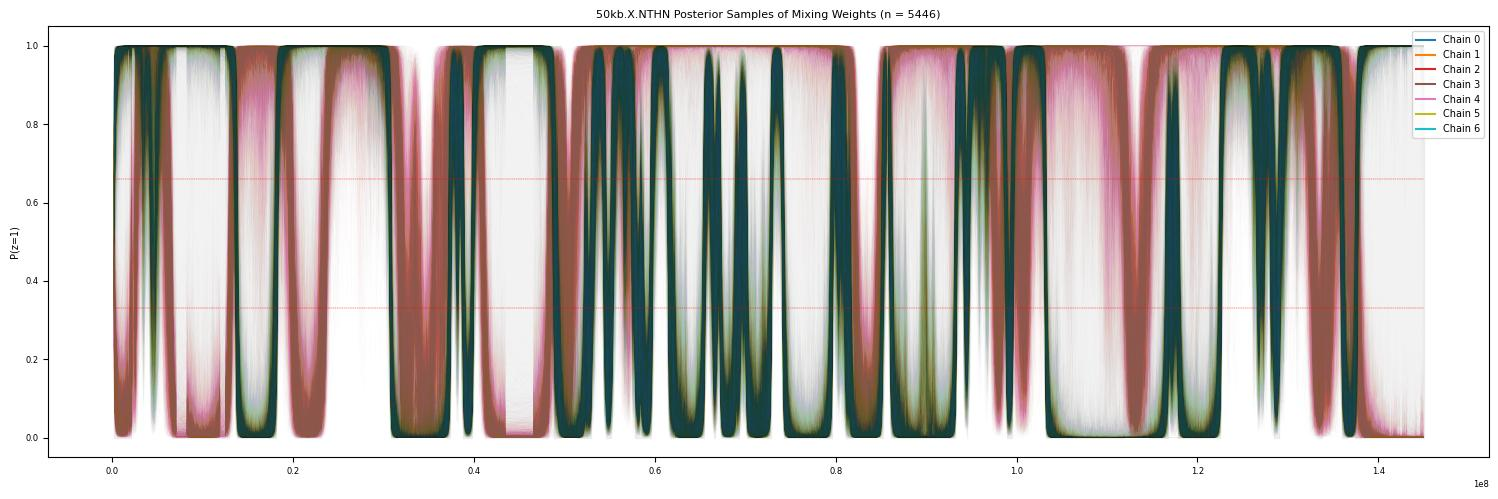

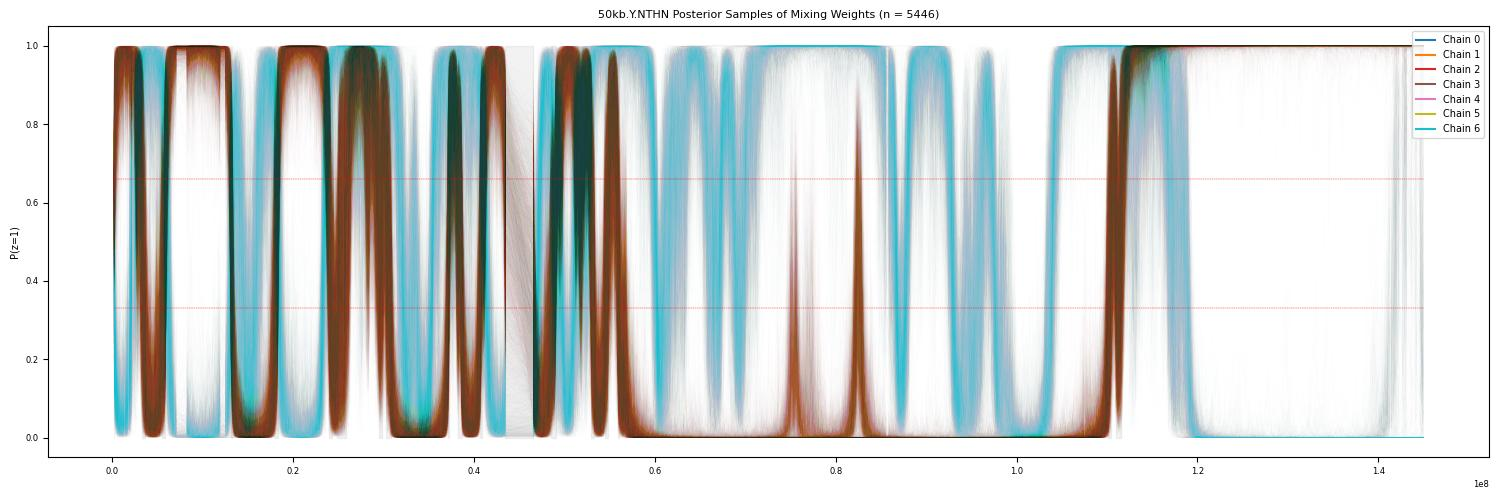

In [63]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')
import matplotlib.lines as mlines

for name, w_stack in w_vars.items():
    x = w_stack["pos"]
    w_mean = w_stack.mean(dim=('sample'))
    total_points = 15_000_000
    n_curves = total_points // len(x)
    n_chains = np.unique(w_stack.chain).shape[0]
    # Subset ncurves // nchains from each chain
    w_subset = w_stack.sel(draw=slice(0,n_curves//n_chains))

    # Example: chain colors
    unique_chains = np.unique(w_subset.chain)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_chains)))
    chain_to_color = {c: colors[i] for i, c in enumerate(unique_chains)}

    fig, ax = plt.subplots(figsize=(15,5))

    # Plot lines with alpha < 1
    for chain_id in unique_chains:
        cols = np.where(w_subset.chain == chain_id)[0]
        for i in cols:
            ax.plot(x, w_subset[:, i], color=chain_to_color[chain_id], alpha=0.05, linewidth=0.05)

    # Create custom legend handles with alpha=1
    handles = [mlines.Line2D([], [], color=chain_to_color[c], label=f'Chain {c}', alpha=1) 
            for c in unique_chains]

    ax.legend(handles=handles, loc="upper right")

    # Grey band

    x_grey = x.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    ax.set_ylabel("P(z=1)")

    plt.title(f"{name} Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
    plt.tight_layout()
    plt.show()



## Count the transitions

Start with just one trace

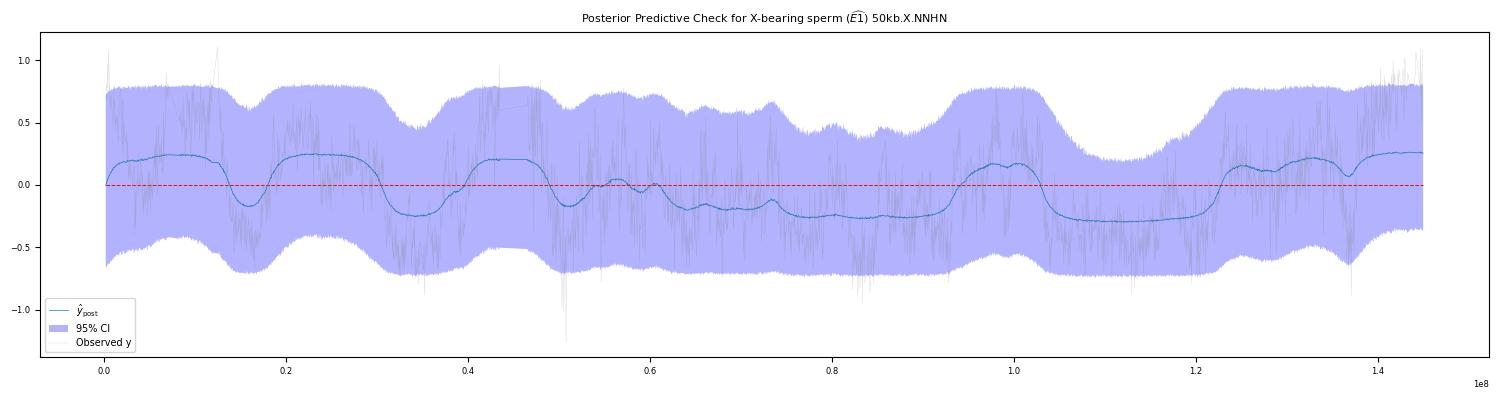

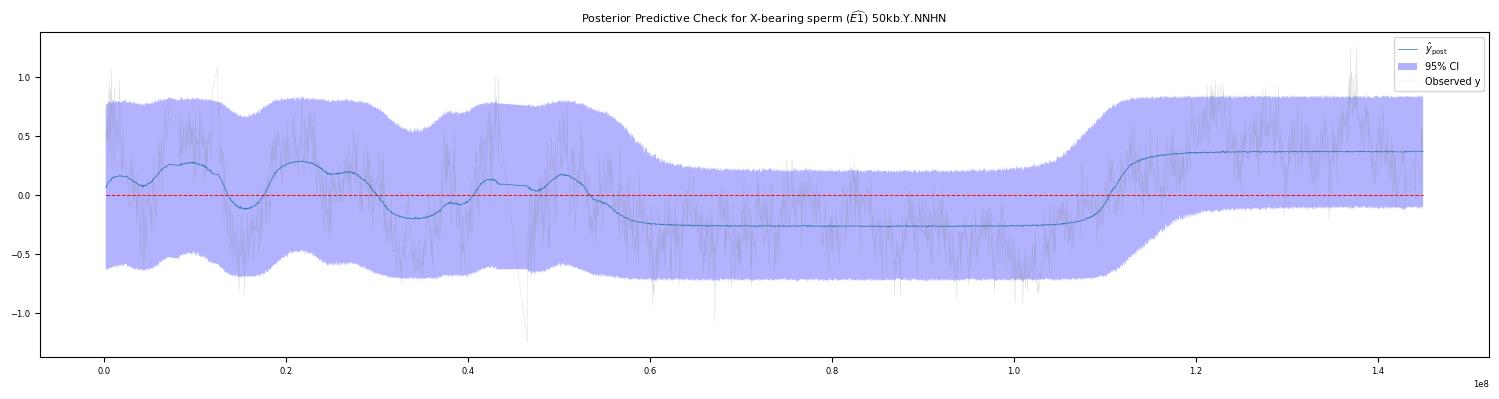

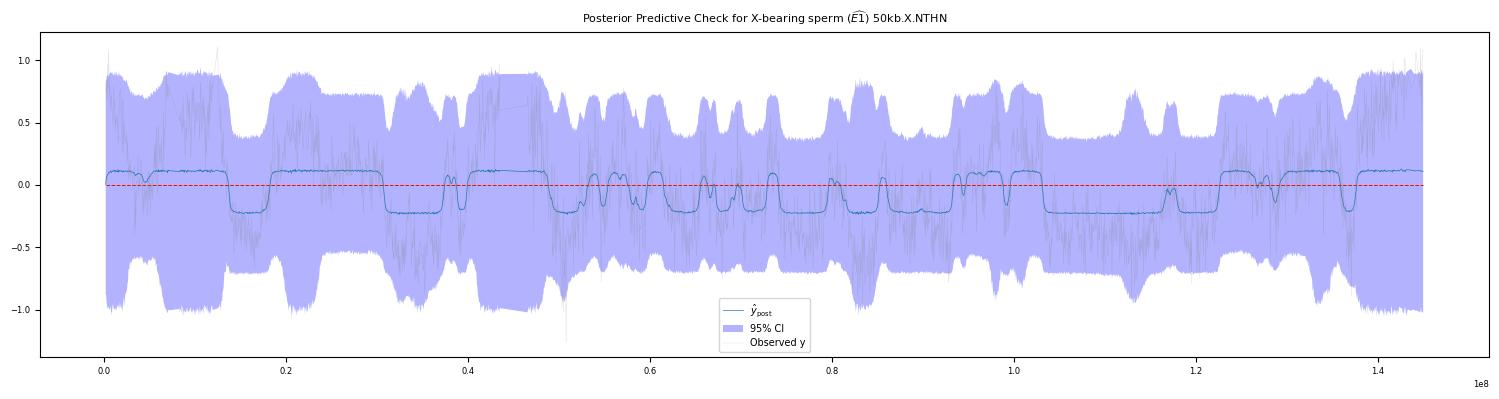

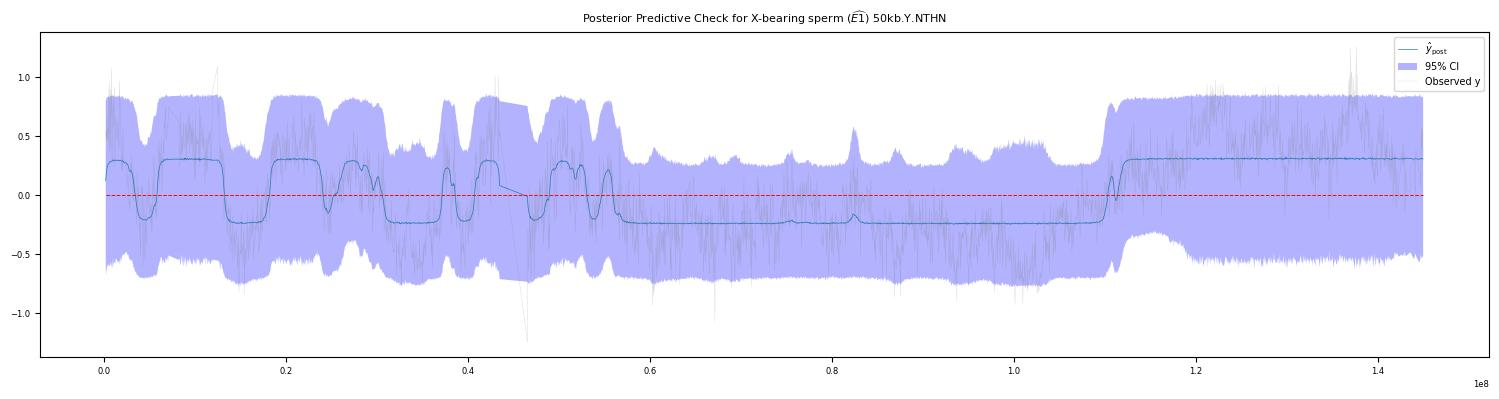

In [64]:
import matplotlib.pyplot as plt
 
for name, trace in traces.items():
    yhat_mean = trace.posterior_predictive.y_hat.mean(dim=('chain', 'draw'))
    yhat_upper = trace.posterior_predictive.y_hat.quantile(0.975, dim=('chain', 'draw'))
    yhat_lower = trace.posterior_predictive.y_hat.quantile(0.025, dim=('chain', 'draw'))

    f,ax = plt.subplots(figsize=(15,4))

    ax.plot(yhat_mean['pos'],yhat_mean, label=r"$\hat{y}_{\mathrm{post}}$", linewidth=0.5)
    ax.hlines(0, min(yhat_mean['pos']), max(yhat_mean['pos']), color='red', linestyle='--', linewidth=0.7)

    ax.fill_between(yhat_mean['pos'], 
                    yhat_upper,
                    yhat_lower,
                    alpha=0.3, label="95% CI", color='blue', ec='None')

    ax.plot(trace.observed_data.y_hat['pos'], trace.observed_data.y_hat, alpha=0.3, color='gray', linewidth=0.3, label="Observed y")

    plt.title("Posterior Predictive Check for X-bearing sperm ($\\widehat{E1}$) " + name)
    plt.legend()
    plt.tight_layout()



In [65]:
import numpy as np
import xarray as xr

def count_crossings(w_stack, threshold=0.5):
    # Boolean mask
    above = w_stack > threshold
    above_shifted = above.shift(pos=-1, fill_value=False)

    # Strip last element (to align shapes after shift)
    above = above.isel(pos=slice(0, -1))
    above_shifted = above_shifted.isel(pos=slice(0, -1))

    # Crossings
    cross_up = ((~above) & (above_shifted)).sum(dim="sample")
    cross_down = ((above) & (~above_shifted)).sum(dim="sample")

    # Attach to Dataset
    result = xr.Dataset({
        "cross_up": cross_up,
        "cross_down": cross_down
    })

    return result.to_dataframe()

def compute_ci_intervals(w_stack):
    """
    We need intervals for transition zones; where the data does not fullfill our CI rule:
    Old: ~(1/3 < w_mean < 2/3) => transition zone
    """
    
    ci_upper, ci_lower = w_stack.quantile([0.05, 0.95], dim=("sample"))
    ci_upper = ci_upper.rename("ci_upper")
    ci_lower = ci_lower.rename("ci_lower")
    in_transition = (~((ci_upper <= 1/3) | (ci_upper >= 2/3) | (ci_lower <= 1/3) | (ci_lower >= 2/3)) | ((ci_upper - ci_lower) > 0.5))

    # All True that come in a row is a transition zone, and should have an ID
    starts = in_transition & ~in_transition.shift(pos=1, fill_value=False)

    # Cumulative sum of starts to get unique IDs
    transition_id = starts.cumsum(dim="pos")

    transition_id = transition_id.where(in_transition, drop=True)

    transition_id = transition_id.rename("CI_ID")

    # Convert to DataFrame
    df = transition_id.rename("CI_ID").to_dataframe()

    return df

def get_ci_type(w_mean, df_summarised):
    res = w_mean.pos[1].values - w_mean.pos[0].values  # fixed resolution
    i_before = df_summarised["start"] - res
    i_after = df_summarised["end"] + res
    w_before = w_mean.sel(pos=i_before.values, method='bfill')
    w_after = w_mean.sel(pos=i_after.values, method='ffill')
    sign_before, sign_after = w_before > 0.5, w_after > 0.5

    types = []
    for before, after in zip(sign_before.values, sign_after.values):
    
        if before == after:
            if before > 0:
                types.append("AA")
            else:
                types.append("BA")
        elif before < after:
            types.append("BA")
        else:
            types.append("AB")

    return types
    


In [66]:
def process_trace(name, trace, threshold=0.5):
    """
    Process a single trace to compute summarized crossing data and save intermediate steps.

    Parameters:
        trace: Trace object containing posterior data.
        threshold (float): Threshold for counting crossings.

    Returns:
        dict: A dictionary containing intermediate and final results.
    """
    # Stack into samples
    w_stack = trace.posterior.w.stack(sample=("chain", "draw"))
    count_stack = count_crossings(w_stack, threshold=threshold)
    ci_stack = compute_ci_intervals(w_stack)
    
    # Merge the two DataFrames, join on what's left in ci_stack (in_transition)
    df_merged = ci_stack.merge(count_stack, left_index=True, right_index=True, how="inner")
    df_merged.CI_ID = df_merged.CI_ID.astype(int)
    
    # Count the crossings per CI_ID
    df_summarised = (
        df_merged
        .reset_index()
        .groupby('CI_ID')
        .agg({
            'cross_up': 'sum',
            'cross_down': 'sum',
            'pos': ['min', 'max', 'count']
        })
    )
    df_summarised.columns = ['n_up', 'n_down', 'start', 'end', 'n_bins']
    
    # Assign CI type
    types = get_ci_type(w_stack.mean(dim='sample'), df_summarised)
    df_summarised = df_summarised.assign(type=types)
    
    # Save all intermediate results in a dictionary
    return {
        "name": name,
        "w_stack": w_stack,
        "df_merged": df_merged,
        "df_summarised": df_summarised
    }

def plot_trace_results(data, bin_size=500_000):
    """
    Plot the posterior mean, transition zones, and crossing histograms.

    Parameters:
        data (dict): Dictionary containing `w_stack`, `df_merged`, and `df_summarised`.
        bin_size (int): Size of bins for the histograms.
    """
    w_stack = data["w_stack"]
    df_merged = data["df_merged"]
    df_summarised = data["df_summarised"]

    x = w_stack["pos"]
    y = w_stack.mean(dim=('sample'))

    f, ax = plt.subplots(figsize=(15, 4))
    ax.plot(x, y, label="Posterior mean", color="black", linewidth=0.8)
    ax.fill_between(
        x,
        w_stack.quantile(0.025, dim=("sample")),
        w_stack.quantile(0.975, dim=("sample")),
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )
    ax.axhline(1/3, color="red", linestyle="--", linewidth=0.4, label="Thresholds")
    ax.axhline(2/3, color="red", linestyle="--", linewidth=0.4)

    # Create a vspan for the transition zones
    for i, row in df_summarised.iterrows():
        start = row['start']
        end = row['end']
        color = '0.8'
        label = "Transition zone" if i == 0 else None
        ax.axvspan(start, end, color=color, alpha=0.3, ec='None', label=label)

    # Plot histograms for each CI_ID
    colormap = {
        "BA": "tab:red",
        "AB": "tab:blue",
        "AA": "darkred",
        "BB": "darkblue"
    }
    colors_used = set()
    for cid, group in df_merged.groupby("CI_ID"):
        type = df_summarised.loc[cid, 'type']
        norm_col = 'cross_up' if type == "BA" else 'cross_down'
        
        if type in ('AA', 'BB'):
            # Which column has the most crossings? Chose that
            norm_col = 'cross_up' if group['cross_up'].sum() > group['cross_down'].sum() else 'cross_down'
            
        norm_factor = group[norm_col].sum()
        
        # Normalize so all crossings sum to 1
        norm1 = group[norm_col] / norm_factor
        #norm2 = group['cross_down'] / norm_factor
        
        bins = np.arange(group.index.min(), group.index.max() + bin_size, bin_size)
        
        label1 = f"AB crosses"
        #label2 = f"BA crosses"

        label1 = label if type not in colors_used else None
        #label2 = label if type not in colors_used else None
        colors_used.add(type)
        ax.hist(x=group.index, weights=norm1, color=colormap[type], bins=bins, alpha=0.4, label=label1)
        #ax.hist(x=group.index, weights=norm2, color=colormap[type], bins=bins, alpha=0.4, label=label2)



    ax.set_title(f"Histogram: Each CI is normalized to sum to 1, binsize={bin_size//1000}kb")
    plt.legend()
    plt.suptitle("Posterior Mean with Transition Zones and Crossing Histograms")
    plt.tight_layout()
    plt.show()

Plotting results for 50kb.X.NNHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,
1,1359,342,200000,400000,5,AA
2,284,2517,13800000,13950000,4,AB
3,2171,317,17850000,18000000,4,BA
4,298,2228,30450000,30600000,4,AB
5,3396,1043,39350000,39700000,8,BA
6,472,2665,48950000,49150000,5,AB
7,9478,7529,53600000,55200000,33,BA
8,1992,4254,57550000,58100000,12,AB
9,4001,2272,59750000,60350000,13,BA


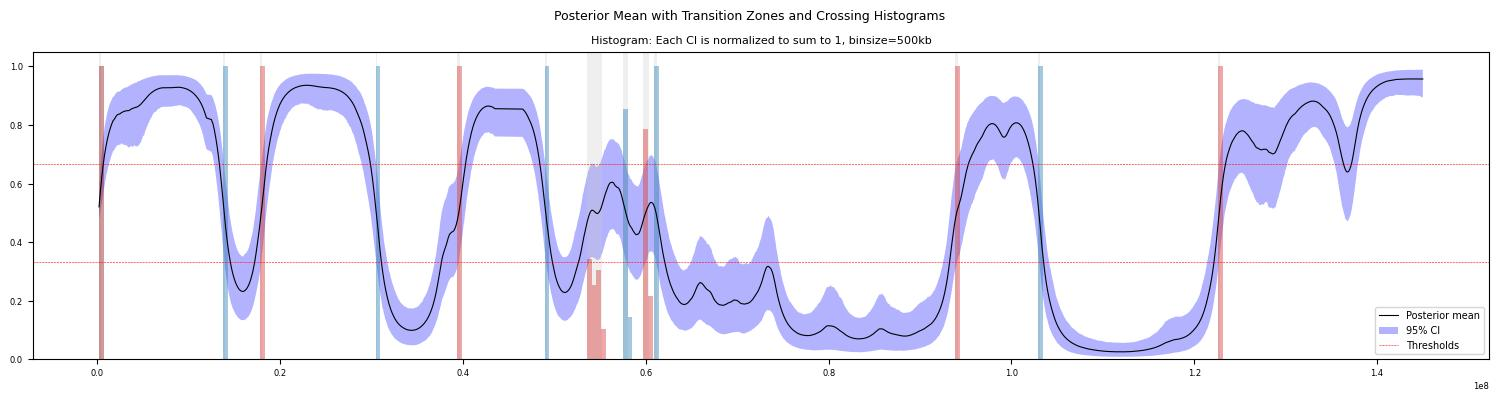

Plotting results for 50kb.Y.NNHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,
1,2509,1011,200000,600000,9,AA
2,521,4490,13150000,13500000,8,AB
3,3934,579,17750000,18100000,8,BA
4,896,2966,29300000,29650000,8,AB
5,5340,1422,40750000,41350000,13,BA
6,10980,11054,43500000,48700000,45,AA
7,937,3564,52700000,53100000,9,AB
8,2188,588,110850000,111100000,6,BA


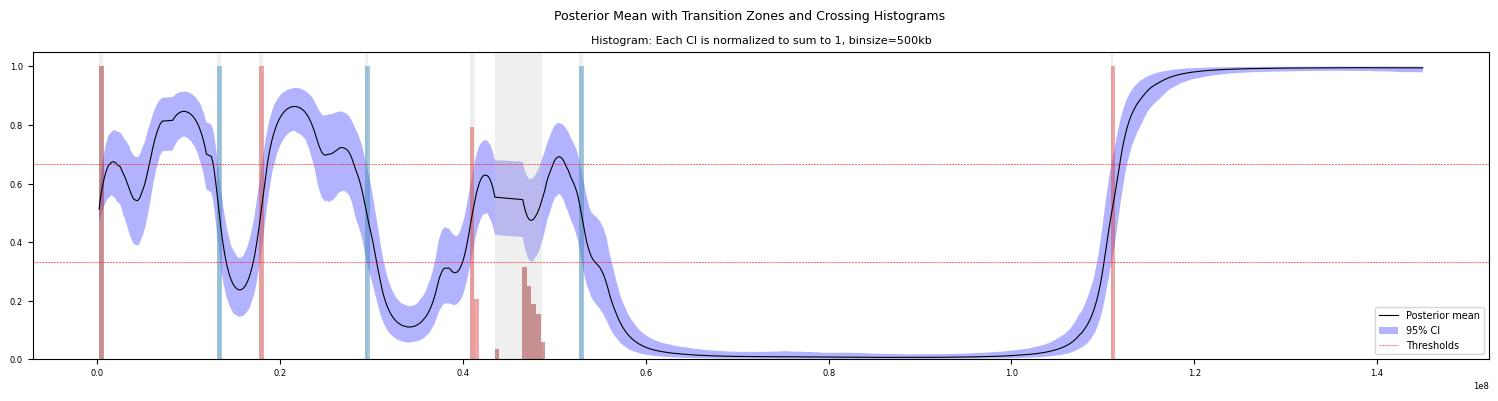

Plotting results for 50kb.X.NTHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,


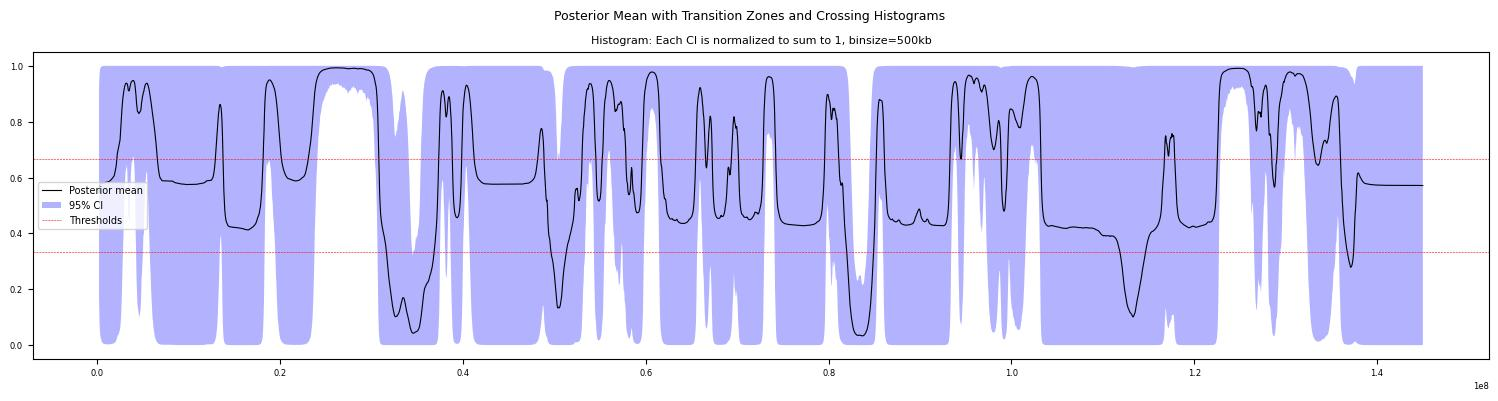

Plotting results for 50kb.Y.NTHN


,n_up,n_down,start,end,n_bins,type
CI_ID,,,,,,


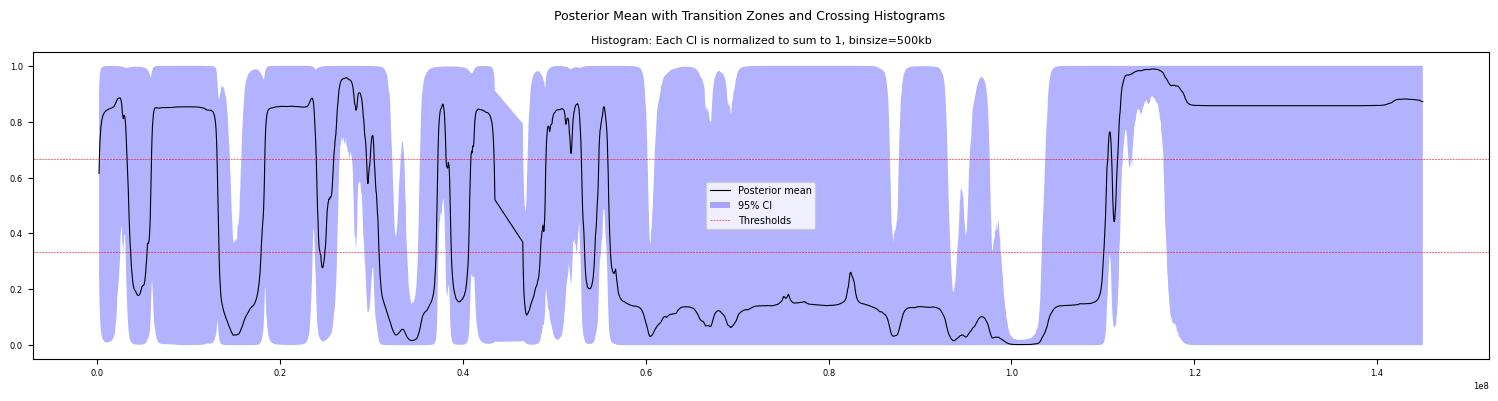

In [67]:
# Process all traces and save results in a dictionary
processed_data = {name: process_trace(name, trace, threshold=0.5) for name, trace in traces.items()}


# Plot results for a specific trace
for name, processed in processed_data.items():
    print(f"Plotting results for {name}")
    display( processed["df_summarised"] )
    plot_trace_results(processed, bin_size=500_000)